In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [39]:
import pygad
import numpy as np
import torch
import os
from ga.fitness import constrained_fitness_func
from ga.mutation import random_float_mutation, custom_mutation
from ga.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config, pixel_cleaning_operation

In [40]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [57]:
config = load_config()

In [42]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [43]:
model = load_model(config["model"]["model_type"], device=device)

Using device: mps


# Loading

In [44]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [45]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [46]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config

In [47]:
def fitness_wrapper(ga_instance, solution, solution_idx):
    return constrained_fitness_func(
        ga_instance, solution, solution_idx, model, input_batch, labels, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    )

In [48]:
def mutation_wrapper(offspring, ga_instance):

    return random_float_mutation(offspring, ga_instance)
    # return custom_mutation(offspring, ga_instance, pixel_std, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], input_batch, apply_pixel_constraints=False)

In [49]:
def on_crossover(ga_instance, offspring):
    offspring = pixel_cleaning_operation(offspring)
    return offspring

In [50]:
def on_generation(ga_instance):

    print(f"\nGeneration {ga_instance.generations_completed} completed with fitness: {ga_instance.last_generation_fitness}")

    input_batch, labels = next(iter(dataloader))
    input_batch, labels = input_batch.to(device), labels.to(device)
    print(f"New batch loaded with first label: {labels[0]}")
    
    # Print the best fitness for this generation
    best_solution, best_solution_fitness, _ = ga_instance.best_solution()
    print(f"Best Fitness = {best_solution_fitness}\n")

    best_perturbation = torch.tensor(best_solution).float().reshape(input_batch.shape[1:])
    top_perturbations.append(best_perturbation)
    print(f"Best perturbation magnitude: {torch.norm(best_perturbation).item()}")

    ########
    # VISUALIZATION
    ########
    if config["visualization"]["visualize"] and ga_instance.generations_completed % config["visualization"]["visualize_every"] == 0:
        print(f"Visualizing")
        # get the current best perturbation
        visualize_images_batch(input_batch, best_perturbation)

    # print(f"Generation {ga_instance.generations_completed}: Current Fitness: Best Fitness = {ga_instance.best_solution()[1]}")


Generation 1 completed with fitness: [-0.19047485 -0.23447495 -0.27424927 -0.26312241 -0.24337875 -0.23232086
 -0.30677261 -0.26401367 -0.2168071  -0.24383423 -0.29016937 -0.27847107
 -0.27869202 -0.25326263 -0.23258926 -0.24851593 -0.26271378 -0.24569733
 -0.28248642 -0.24526016]
New batch loaded with first label: 645
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


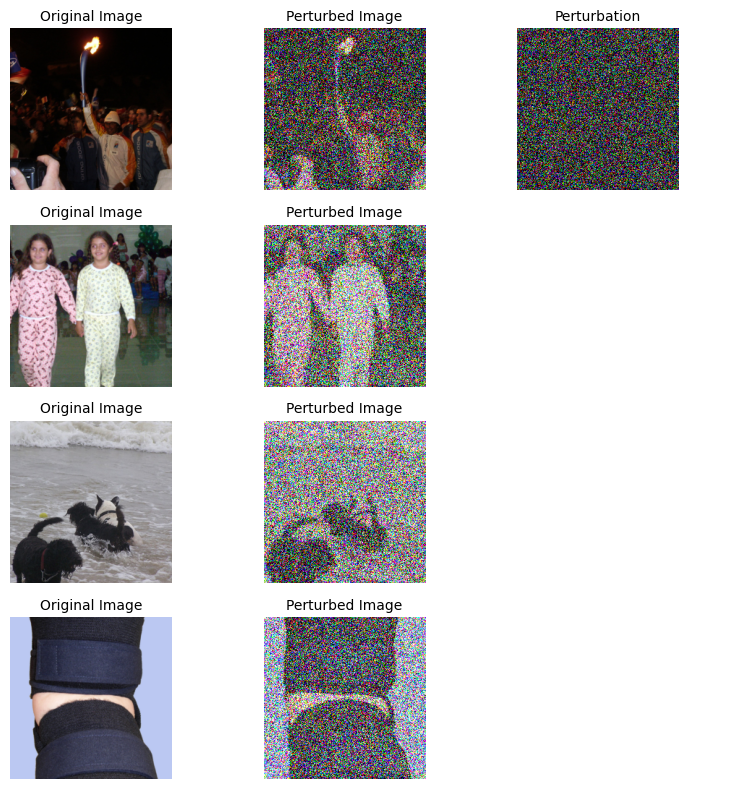


Generation 2 completed with fitness: [-0.19047485 -0.35543274 -0.26695267 -0.33171066 -0.36054947 -0.36663193
 -0.25430847 -0.2796579  -0.31405136 -0.36880478 -0.26517853 -0.33194077
 -0.37535522 -0.36003448 -0.33228104 -0.30287186 -0.40908401 -0.35666016
 -0.30086533 -0.3161528 ]
New batch loaded with first label: 412
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


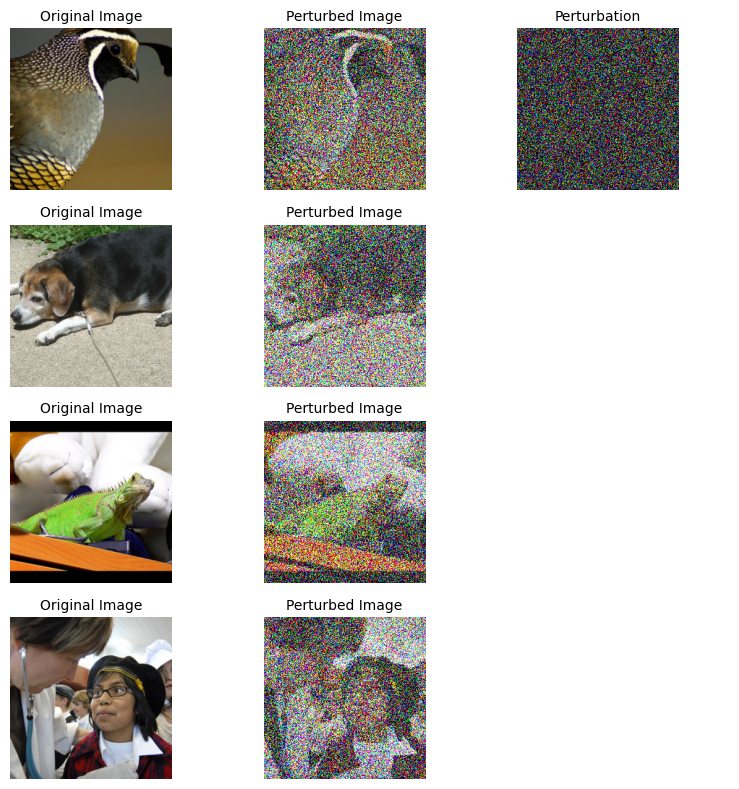


Generation 3 completed with fitness: [-0.19047485 -0.38415787 -0.41665787 -0.40113083 -0.41471252 -0.36618286
 -0.32224091 -0.31934708 -0.3660762  -0.41307373 -0.33194321 -0.39508636
 -0.3339949  -0.40171158 -0.38477905 -0.3493985  -0.39853653 -0.44542374
 -0.32219513 -0.33259842]
New batch loaded with first label: 723
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


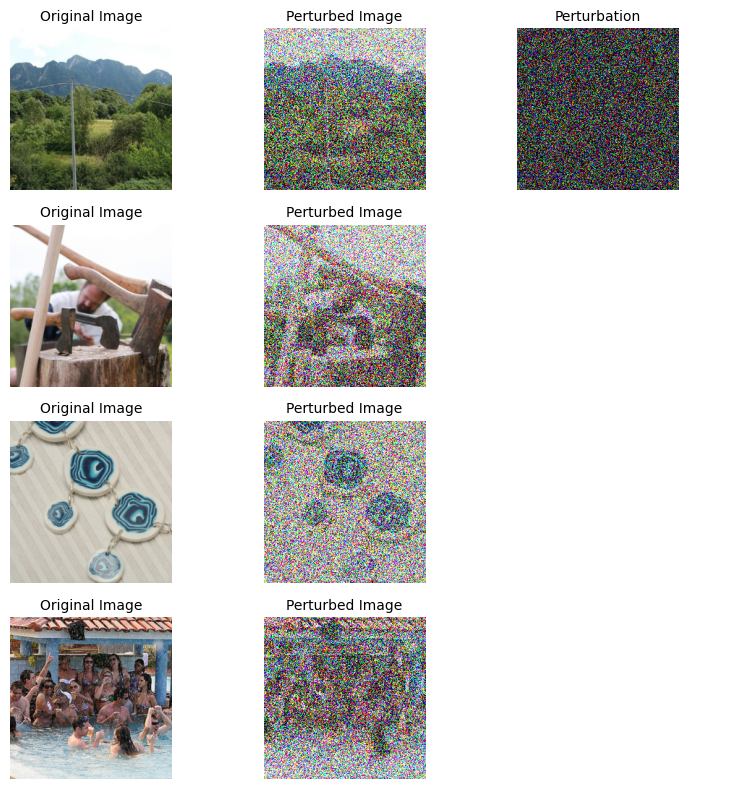


Generation 4 completed with fitness: [-0.19047485 -0.40018265 -0.41205994 -0.44228394 -0.47626205 -0.44533783
 -0.47550369 -0.5233931  -0.43058945 -0.52619049 -0.48198624 -0.43107193
 -0.41108643 -0.4292749  -0.4437114  -0.4439946  -0.46416168 -0.44275223
 -0.42567062 -0.52338791]
New batch loaded with first label: 25
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


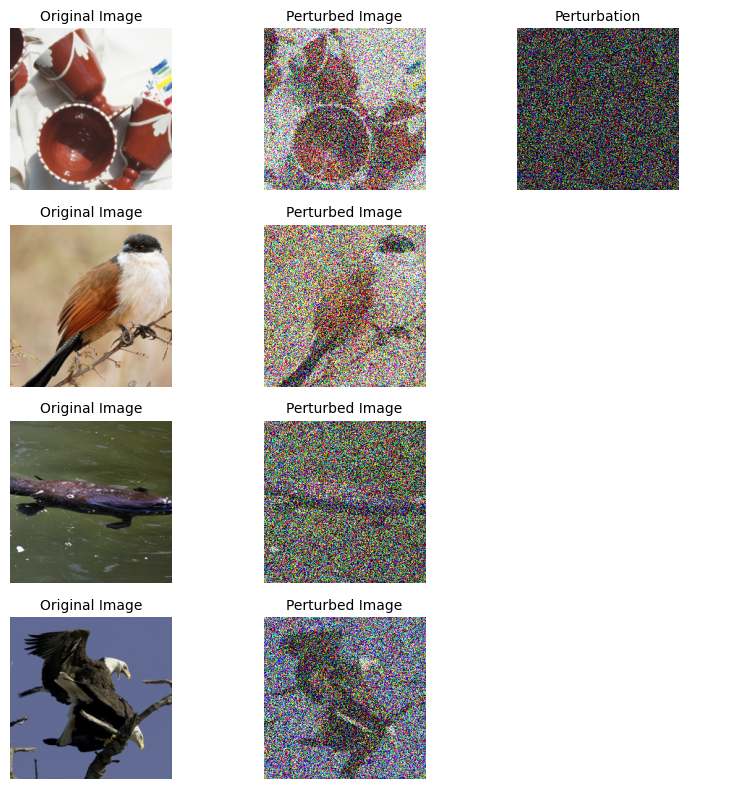


Generation 5 completed with fitness: [-0.19047485 -0.72831665 -0.76206375 -0.64223145 -0.65701096 -0.51607498
 -0.55036819 -0.47101517 -0.62727325 -0.51484833 -0.50098145 -0.46923233
 -0.63921158 -0.64664093 -0.67404099 -0.68997559 -0.61698654 -0.74370163
 -0.62676697 -0.6316246 ]
New batch loaded with first label: 370
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


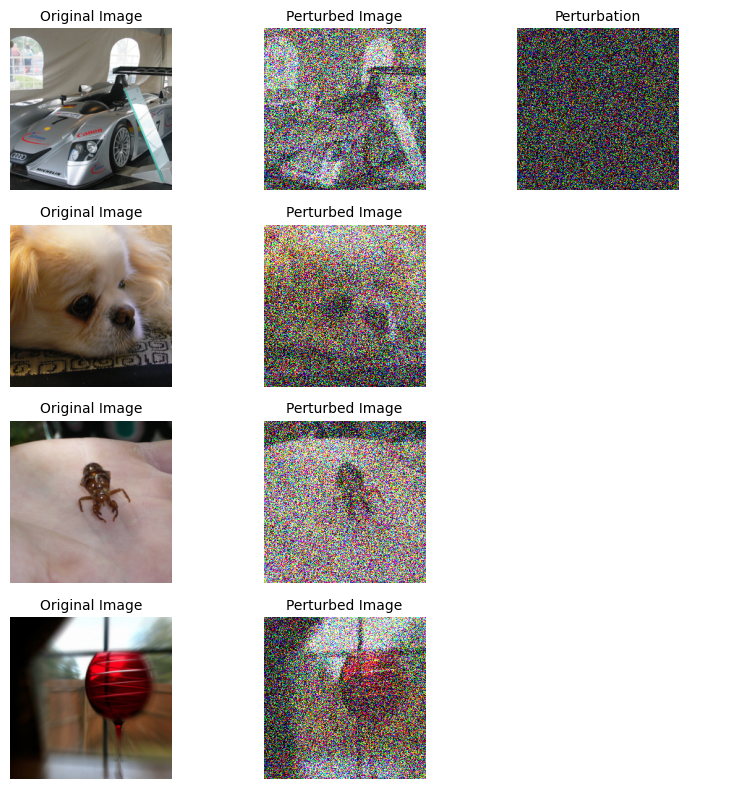


Generation 6 completed with fitness: [-0.19047485 -0.56663605 -0.58642487 -0.59984283 -0.67544525 -0.6860408
 -0.62921249 -0.65804733 -0.6136232  -0.64405716 -0.58152313 -0.5816095
 -0.58666519 -0.57202469 -0.57575226 -0.62044006 -0.58213074 -0.58250153
 -0.68953262 -0.58786133]
New batch loaded with first label: 599
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


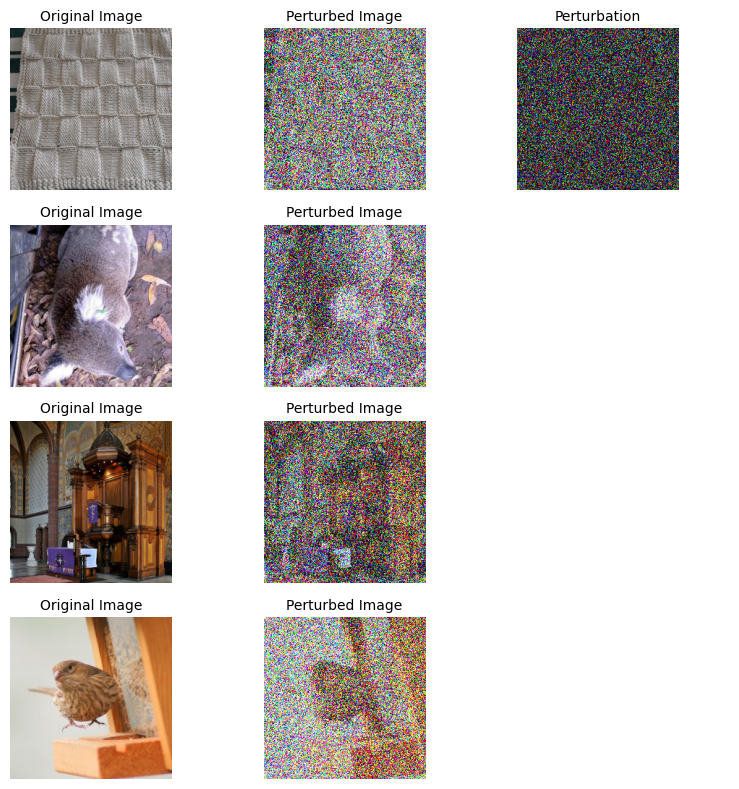


Generation 7 completed with fitness: [-0.19047485 -0.69239822 -0.88567017 -0.86230927 -0.67188995 -0.6916745
 -0.70365997 -0.67306931 -0.88843369 -0.87567551 -0.6666835  -0.70601059
 -0.67586731 -0.83957291 -0.70271393 -0.73407898 -0.67347031 -0.84106689
 -0.65980225 -0.65548431]
New batch loaded with first label: 940
Best Fitness = -0.190474853515625

Best perturbation magnitude: 223.7349395751953
Visualizing


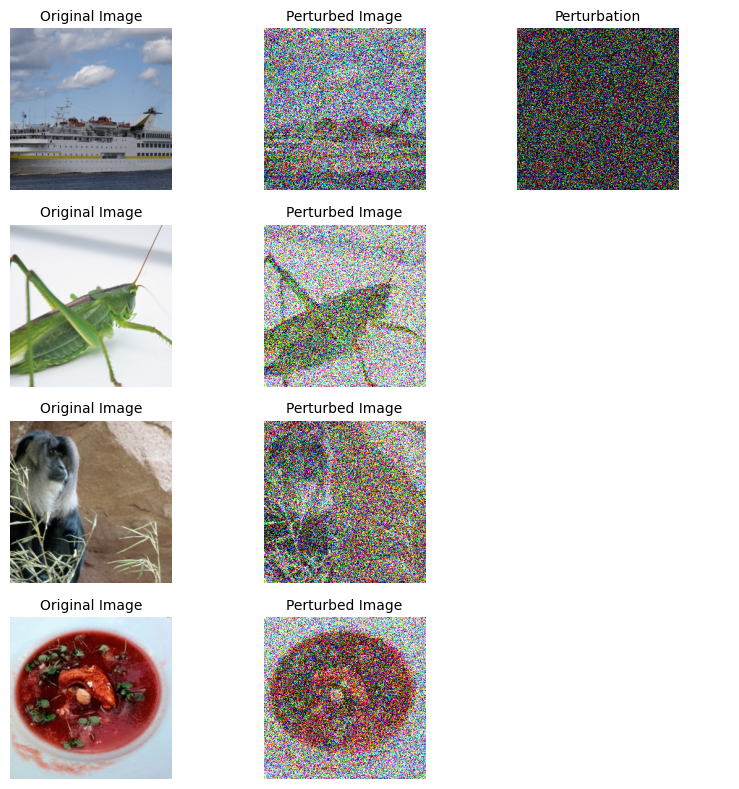

KeyboardInterrupt: 

In [56]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    mutation_percent_genes=config["ga"]["mutation_percent_genes"],
    crossover_type=config["ga"]["crossover_type"],
    crossover_probability=config["ga"]["crossover_probability"],
    mutation_type=mutation_wrapper,
    mutation_probability=config["ga"]["mutation_probability"],
    fitness_func=fitness_wrapper,
    on_generation=on_generation,
    on_crossover=on_crossover,
)

ga_instance.run()

##### Best fitness records
- no pixel constraints: 0.84
- pixel constraint weight 1: 0.80
- above + max perturbation mag 100: 

In [ ]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [19]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: 0.828125


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


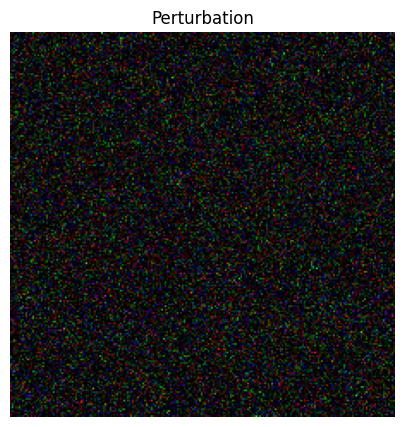

In [32]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

# Metrics

### GoogLeNet

In [22]:
evaluate_without_perturbation(model, dataloader)

Accuracy without perturbation: 0.69772


0.69772

In [23]:
evaluate_with_perturbation(model, dataloader, universal_perturbation)

Accuracy with perturbation: 0.37964


0.37964

### ViT b 16

In [33]:
evaluate_without_perturbation(model, dataloader)
evaluate_with_perturbation(model, dataloader, universal_perturbation)

Accuracy without perturbation: 0.69772


KeyboardInterrupt: 